# Model Evaluation under Covariate Shift (Domain Adaptation)

In this notebook, we simulate a Non-Linear Covariate Shift using the `Two Moons` dataset.
We split the data into two domains with a deliberate overlap to act as an anchor:
* **Source Domain (ID):** Samples where $X \le 0$.
* **Target Domain (OOD):** Samples where $X \ge -0.1$.

We will evaluate multiple models (Linear, Tree-based, Neural Network, and TabPFN) to observe how their decision boundaries extrapolate into unseen data, and finally test if a linear alignment method (**CORAL**) can mitigate the shift.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from scipy.linalg import fractional_matrix_power
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier 
import os
import tabpfn_client

import warnings
warnings.filterwarnings('ignore')

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(f"Using device: {device}")

# ==========================================
# 1. Data Generation & Domain Split
# ==========================================
X_base_std, y_base_std = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_base_std[:, 0] -= 0.5  # Center the dataset at X=0

# Source Domain (In-Distribution)
source_mask = X_base_std[:, 0] <= 0
X_source_std, y_source_std = X_base_std[source_mask], y_base_std[source_mask]

# Target Domain (Out-of-Distribution) with slight overlap starting at -0.1
target_mask = X_base_std[:, 0] >= -0.1
X_target_std, y_target_std = X_base_std[target_mask], y_base_std[target_mask]

# ==========================================
# 2. General Evaluation Function
# ==========================================
def train_and_eval(model, X_train, y_train, X_test, y_test):
    """Trains the model and returns accuracies for both source and target."""
    model.fit(X_train, y_train)
    acc_src = accuracy_score(y_train, model.predict(X_train))
    acc_tgt = accuracy_score(y_test, model.predict(X_test))
    return acc_src, acc_tgt

### Visualizing the Covariate Shift

We first visualize the spatial distribution of the data to illustrate the simulated Domain Shift.

In the plot below, we visualize the entire `Two Moons` dataset. We then demarcate the domains:
* The area to the left (up to $X=0$) is our **Source Domain**. This is the only environment our models will see during training.
* The area to the right (starting from $X=-0.1$) is our **Target Domain**. 
* The highlighted yellow band represents the **Overlap Region** ($-0.1 \le X \le 0$). This shared geometric space acts as an anchor, giving the models a slight hint of the target distribution and helping alignment algorithms like CORAL to find a mapping between the domains.

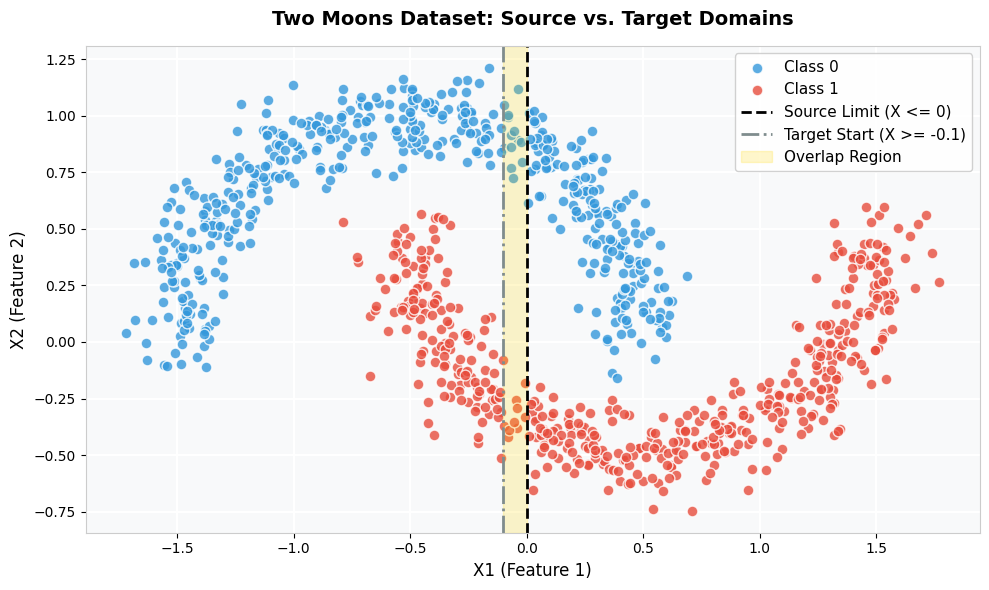

In [ ]:
# ==========================================
# 3. Visualizing the Data & The Domain Split
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# Scatter the entire base dataset
ax.scatter(X_base_std[y_base_std==0, 0], X_base_std[y_base_std==0, 1], 
           c=color_blue, edgecolors='white', s=60, alpha=0.8, label='Class 0')
ax.scatter(X_base_std[y_base_std==1, 0], X_base_std[y_base_std==1, 1], 
           c=color_red, edgecolors='white', s=60, alpha=0.8, label='Class 1')

# Draw the domain boundaries
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Source Limit (X <= 0)')
ax.axvline(x=-0.1, color='#7f8c8d', linestyle='-.', linewidth=2, label='Target Start (X >= -0.1)')

# Highlight the overlap region
ax.axvspan(-0.1, 0, color='gold', alpha=0.2, label='Overlap Region')

# Aesthetics
ax.set_title("Two Moons Dataset: Source vs. Target Domains", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("X1 (Feature 1)", fontsize=12)
ax.set_ylabel("X2 (Feature 2)", fontsize=12)
ax.set_facecolor('#f8f9fa')
ax.grid(True, color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)

# Clean borders
for spine in ax.spines.values():
    spine.set_color('#cccccc')

ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

## Base Models Evaluation

We will train standard classifiers exclusively on the Source Domain and test their generalization on the Target Domain.

### Linear Baselines: Standard Logistic Regression

We begin our evaluation with a standard linear model. Logistic Regression provides a highly interpretable baseline, learning a simple linear decision boundary. 

**The Importance of Feature Scaling:**
While our current dataset is low-dimensional (2D), we apply `StandardScaler` to normalize our features ($mean=0$, $variance=1$). This is a machine learning best practice that ensures stable and fast mathematical convergence for the solver. Furthermore, it sets up a robust pipeline for when we later introduce high-dimensional biological data and scale-sensitive regularization techniques.

In [13]:
# ==========================================
# 1. Feature Scaling
# ==========================================
# Fit scaler ONLY on Source domain to prevent data leakage
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source_std)
X_target_scaled = scaler.transform(X_target_std)

# ==========================================
# 2. Model Training
# ==========================================
lr_model = LogisticRegression(random_state=42)
lr_src_acc, lr_tgt_acc = train_and_eval(lr_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"Logistic Regression Accuracy on Source Data: {lr_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"Logistic Regression Accuracy on Target Data: {lr_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
Logistic Regression Accuracy on Source Data: 0.981

--- Target Domain (OOD) ---
Logistic Regression Accuracy on Target Data: 0.693



### Tree-Based Ensemble: XGBoost
Next, we evaluate XGBoost, a powerful gradient boosting framework. Unlike linear models, tree-based models learn decision boundaries through orthogonal splits (axis-parallel cuts). We expect a highly complex, step-like boundary that may overfit the Source domain and struggle to extrapolate smoothly into the curved Target domain.

In [14]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_src_acc, xgb_tgt_acc = train_and_eval(xgb_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"XGBoost Accuracy on Source Data: {xgb_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"XGBoost Accuracy on Target Data: {xgb_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
XGBoost Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
XGBoost Accuracy on Target Data: 0.816



In [12]:
# Initialize and train MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

mlp_src_acc, mlp_tgt_acc = train_and_eval(mlp_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"MLP Accuracy on Source Data: {mlp_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"MLP Accuracy on Target Data: {mlp_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
MLP Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
MLP Accuracy on Target Data: 0.773



### Foundation Models: TabPFN
Finally, we test TabPFN, a Prior-Data Fitted Network that performs in-context learning for tabular data without traditional weight optimization. It relies on a Transformer architecture pre-trained on synthetic datasets. We test how an attention-based model handles Covariate Shift.

**Note on TabPFN Usage:**
Recent updates to the `tabpfn` library require a free API token to access the foundation model. To run the cell below locally:
1. Open https://ux.priorlabs.ai in a browser and log in (or register).
2. Accept the license on the Licenses tab.
3. Copy your API token from the account page.
4. Replace `"YOUR_API_KEY_HERE"` in the code below with your actual token.

In [ ]:
# ==========================================
# 1. TabPFN License & Initialization
# ==========================================
TABPFN_TOKEN = "YOUR_API_KEY_HERE" 

# Applying the token to the environment and the client
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
tabpfn_client.set_access_token(TABPFN_TOKEN)

# Initialize TabPFN
tabpfn_model = TabPFNClassifier(device="cpu") 

# ==========================================
# 2. Model Training & Evaluation
# ==========================================
tabpfn_src_acc, tabpfn_tgt_acc = train_and_eval(tabpfn_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"TabPFN Accuracy on Source Data: {tabpfn_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"TabPFN Accuracy on Target Data: {tabpfn_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
TabPFN Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
TabPFN Accuracy on Target Data: 0.825



### Decision Boundary Comparison under Covariate Shift
To evaluate OOD extrapolation, we visualize the learned decision boundaries over the entire dataset space. 
This grid allows us to visually compare the linear rigidity of Logistic Regression, the orthogonal splits of XGBoost, and the flexible curves of the MLP and TabPFN.

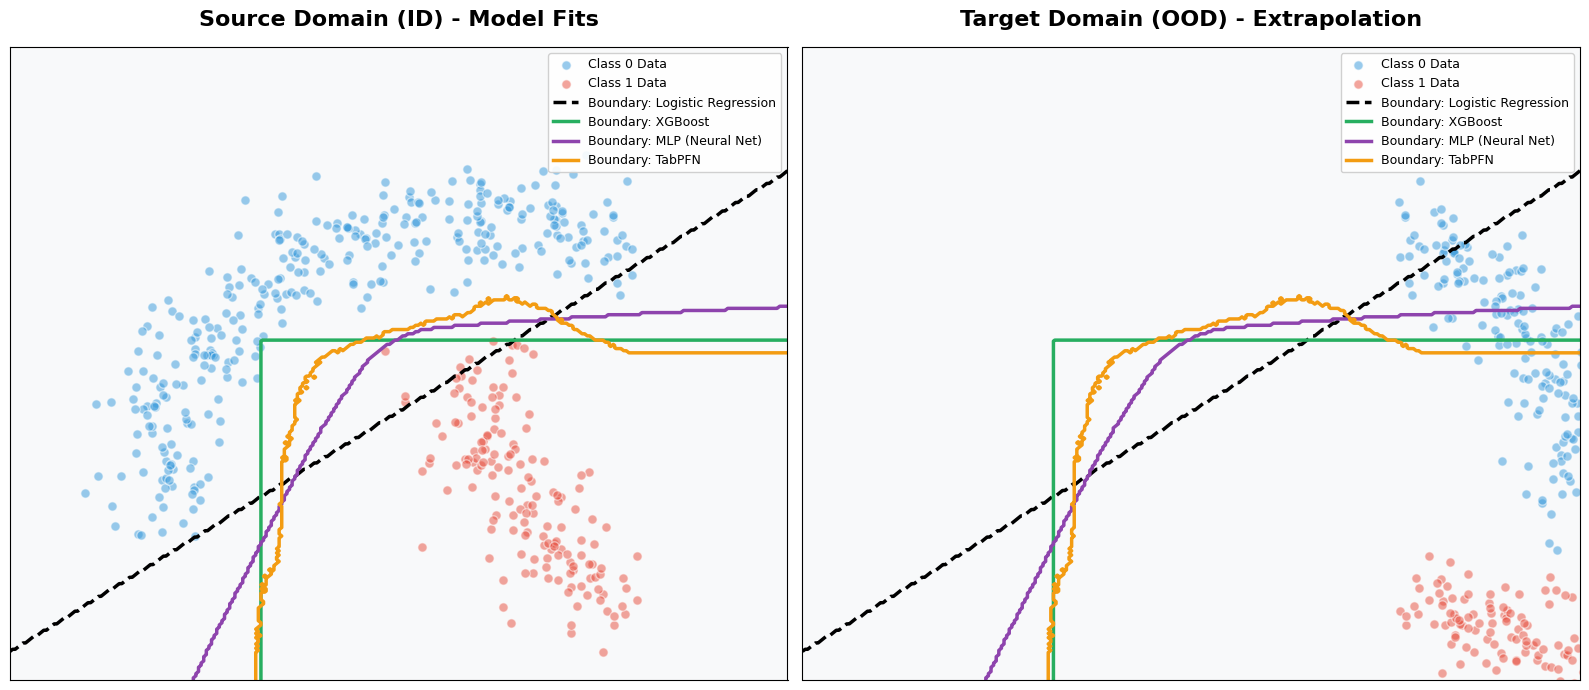

In [22]:
# Create a dictionary of our trained models
trained_models = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model,
    'MLP (Neural Net)': mlp_model,
    'TabPFN': tabpfn_model
}

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(16, 7))

color_class_0 = '#3498db'
color_class_1 = '#e74c3c'

# Define distinct colors and styles for each model's boundary line
model_styles = {
    'Logistic Regression': {'color': 'black', 'style': '--'},
    'XGBoost': {'color': '#27ae60', 'style': '-'},      # Green
    'MLP (Neural Net)': {'color': '#8e44ad', 'style': '-'}, # Purple
    'TabPFN': {'color': '#f39c12', 'style': '-'}        # Orange
}

def plot_overlay_boundaries(ax, X_data, y_data, title):
    # Set grid limits based on scaled data
    x_min, x_max = -2.5, 2.5
    y_min, y_max = -2.5, 2.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    
    # Scatter the actual data points
    ax.scatter(X_data[y_data==0, 0], X_data[y_data==0, 1], c=color_class_0, edgecolors='white', alpha=0.5, s=45, label='Class 0 Data')
    ax.scatter(X_data[y_data==1, 0], X_data[y_data==1, 1], c=color_class_1, edgecolors='white', alpha=0.5, s=45, label='Class 1 Data')
    
    # Loop through models and draw ONLY their decision boundaries (Z = 0.5)
    for name, model in trained_models.items():
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        # levels=[0.5] draws the line exactly where the model switches from predicting 0 to 1
        ax.contour(xx, yy, Z, levels=[0.5], colors=[model_styles[name]['color']], 
                   linestyles=model_styles[name]['style'], linewidths=2.5)
        # We use a dummy plot for the legend to represent the line
        ax.plot([], [], color=model_styles[name]['color'], linestyle=model_styles[name]['style'], linewidth=2.5, label=f'Boundary: {name}')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#f8f9fa') # Light gray background for contrast
    
    # Organize the legend
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Plot Source Only
plot_overlay_boundaries(ax_s, X_source_scaled, y_source_std, "Source Domain (ID) - Model Fits")

# Plot Target Only
plot_overlay_boundaries(ax_t, X_target_scaled, y_target_std, "Target Domain (OOD) - Extrapolation")

plt.tight_layout()
plt.show()

### Systematic Comparison: Model Generalization under Covariate Shift

Visualizing the accuracy side-by-side reveals the strengths and critical extrapolation weaknesses of different architectures across domains:

* **The Source Domain (ID):** All models perform exceptionally well, successfully learning the underlying pattern of the training distribution. Complex models like XGBoost and MLP achieve near-perfect accuracy by flexibly adapting to the non-linear data.
* **The Target Domain (OOD):** The non-linear Covariate Shift provides a rigorous evaluation of out-of-distribution (OOD) generalization. Logistic Regression fails due to its strict linear rigidity. XGBoost's orthogonal splits fail to generalize to the newly inverted curve. Even flexible models like MLP and TabPFN suffer severe performance drops—demonstrating that without domain adaptation, models struggle to extrapolate meaningfully to unseen distributions.

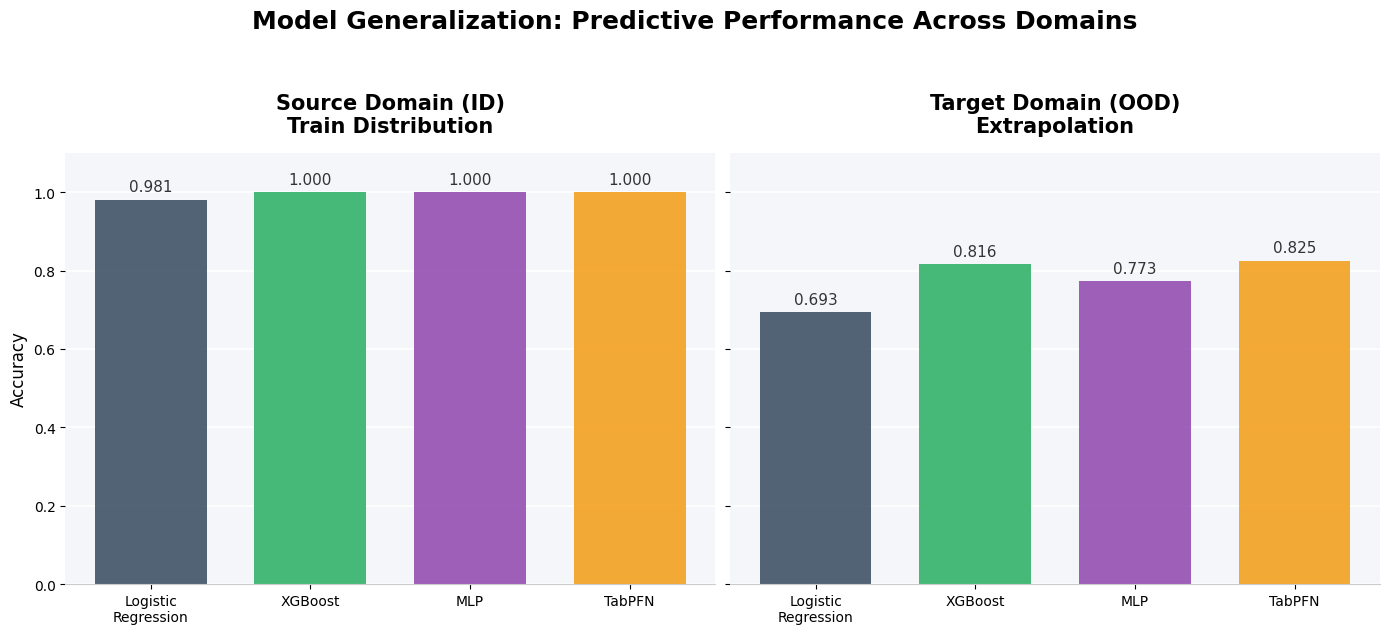

In [23]:
# ==========================================
# 6. Final Performance Comparison Bar Chart
# ==========================================
# Aggregate the accuracies we computed earlier
model_names = ['Logistic\nRegression', 'XGBoost', 'MLP', 'TabPFN']
src_accuracies = [lr_src_acc, xgb_src_acc, mlp_src_acc, tabpfn_src_acc]
tgt_accuracies = [lr_tgt_acc, xgb_tgt_acc, mlp_tgt_acc, tabpfn_tgt_acc]

# We use the exact same color palette defined in the overlay plot
bar_colors = ['#34495e', '#27ae60', '#8e44ad', '#f39c12'] 
# (Dark Slate for LR, Green for XGB, Purple for MLP, Orange for TabPFN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Plot Source Domain ---
bars_src = ax1.bar(model_names, src_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax1.set_title('Source Domain (ID)\nTrain Distribution', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)

# --- Plot Target Domain ---
bars_tgt = ax2.bar(model_names, tgt_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax2.set_title('Target Domain (OOD)\nExtrapolation', fontsize=15, fontweight='bold', pad=15)

# Function to automatically attach text labels above each bar
def attach_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='500', color='#333333')

attach_labels(bars_src, ax1)
attach_labels(bars_tgt, ax2)

# Clean Aesthetics
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.1) # Leave headroom for the text labels
    ax.set_facecolor('#f4f6f9') # Soft gray background like ggplot
    ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_axisbelow(True) # Put grid behind bars
    
    # Remove outer spines for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    # Thicken x-axis line slightly
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')

plt.suptitle("Model Generalization: Predictive Performance Across Domains", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()